In [39]:
import sys
!{sys.executable} -m pip install pandas seaborn scikit-learn numpy shap lime

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import svm
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from util import save_cm, read_data
import shap
import lime

In [41]:
def train_gaussian_naive_bias_model(X_train, y_train):
    gnb = GaussianNB()
    gnb.fit(X_train, y_train)
    return gnb

In [42]:
def explain_model_using_shap(X_train,X_test, model,model_type, model_name, feature_names):
    explainer = shap.KernelExplainer(model.predict, X_train)
    shap_values = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test, feature_names, show=False)
    plt.tight_layout()
    plt.savefig(f"./shap_summary_plots/{model_type}/{model_name}.png", dpi=300)
    plt.close()

In [43]:
def explain_model_using_lime(X_train,X_test, model,model_type, model_name, feature_names):
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train.values, feature_names=feature_names, class_names=['No Death Event', 'Death Event'], 
        discretize_continuous=True, mode='classification'
    )
    i = 0  
    sample = X_test.values[i].reshape(1, -1)
    print(sample.shape)
    lime_explanation = lime_explainer.explain_instance(sample[0], model.predict_proba, num_features=len(feature_names))
    lime_explanation.save_to_file(f"./lime_summaries/{model_type}/{model_name}.html")

### Gaussian Naïve Bayes

The **Gaussian Naïve Bayes** classifier is a probabilistic model based on **Bayes’ theorem**, assuming that features follow a **Gaussian distribution**. It does not have hyperparameters to tune but relies on the **mean and variance** for each feature.


In [ ]:
def run_gnn():
    X, y, feature_names = read_data()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    model_name= f'gnn'
    model= train_gaussian_naive_bias_model(X_train, y_train)
    y_pred = model.predict(X_test)
    pred= model.predict(X_train)
    f1_train = round(f1_score(y_train, pred, average='macro'),3)
    accuracy_train= round(accuracy_score(y_train, pred),3)
    f1_test = round(f1_score(y_test, y_pred, average='macro'),3)
    accuracy_test= round(accuracy_score(y_test, y_pred),3)
    print(
        f"GNN Training Results:\n"
        f"  Accuracy: {accuracy_train:.3f}\n"
        f"  F1 Score: {f1_train:.3f}\n"
        f"Test Results:\n"
        f"  Accuracy: {accuracy_test:.3f}\n"
        f"  F1 Score: {f1_test:.3f}"
    )
    cm = confusion_matrix(y_test, y_pred)
    save_cm('gnn',model_name, cm)
    explain_model_using_shap(X_train,X_test, model,'gnn', model_name, feature_names)
    explain_model_using_lime(X_train,X_test, model,'gnn', model_name, feature_names)

In [45]:
run_gnn()

Using 142 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Outliers from age feature removed
Outliers from creatinine_phosphokinase feature removed
Outliers from ejection_fraction feature removed
Outliers from platelets feature removed
Outliers from serum_creatinine feature removed
Outliers from time feature removed
KNN Training Results:
  Accuracy: 0.866
  F1 Score: 0.840
Test Results:
  Accuracy: 0.852
  F1 Score: 0.719


100%|██████████| 61/61 [00:02<00:00, 22.31it/s]


(1, 12)


/Users/surafel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


### Logistic Regression Classifier

Logistic Regression was implemented using the `scikit-learn` (`sklearn`) library to classify the images. Various regularization techniques were applied to improve generalization and prevent overfitting:

- **L1 (Lasso)**
- **L2 (Ridge)**
- **ElasticNet** (with an `l1_ratio` of **0.5** to balance L1 and L2 penalties)

To ensure robustness:

- **Class weights were balanced** in all of the experiments.

Different solvers were explored to optimize the model’s performance:

- **LBFGS**
- **Newton-CG**
- **SAGA**
- **SAG**

Each solver offers distinct advantages in handling optimization and convergence during training.

### Solver and Penalty Compatibility

| Solver     | Supported Penalties                  |
|------------|--------------------------------------|
| lbfgs      | l2, None                             |
| newton-cg  | l2, None                             |
| sag        | l2, None                             |
| saga       | elasticnet, l1, l2, None             |
**Table:** Supported regularization penalties for each solver used with Logistic Regression in scikit-learn.

In [46]:
def train_logistic_regression_model(X_train, y_train, penalty, C, solver, l1_ratio=None):
    model = LogisticRegression(C=C, class_weight='balanced', solver=solver, penalty=penalty, l1_ratio=l1_ratio)
    model.fit(X_train, y_train)
    return model

In [47]:
def enumerate_lr_models(X_train, y_train, C):
    model1= train_logistic_regression_model(X_train, y_train, 'l2', C, 'lbfgs')
    model2= train_logistic_regression_model(X_train, y_train, 'l2', C, 'newton-cg')
    model3= train_logistic_regression_model(X_train, y_train, 'l2', C, 'sag')
    model4= train_logistic_regression_model(X_train, y_train, 'l2', C, 'saga')
    model5= train_logistic_regression_model(X_train, y_train, 'elasticnet', C, 'saga', 0.5)
    model6= train_logistic_regression_model(X_train, y_train, 'l1', C, 'saga')
    return ['logistic_regression_l2_balanced_lbfgs', 'logistic_regression_l2_balanced_newton-cg', 'logistic_regression_l2_balanced_sag','logistic_regression_l2_balanced_saga', 'logistic_regression_elasticnet_balanced_saga', 'logistic_regression_l1_balanced_sag'],[model1, model2, model3, model4, model5, model6]
    

In [48]:
def run_logistic_regression():
    X, y,feature_names = read_data()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    file= open('./training_results/logistic_regression.csv', mode='w', newline='', encoding='utf-8')
    header= 'C,penalty,solver,accuracy_train,f1_train,accuracy_test,f1_test'
    file.write(header)
    for C in range(1,15,5):
        C=C/10
        model_names, models=enumerate_lr_models(X_train, y_train, C)
        for model_index in range(len(models)):
            model= models[model_index]
            model_name= f'{model_names[model_index]}_{C}'
            y_pred = model.predict(X_test)
            pred= model.predict(X_train)
            f1_train = round(f1_score(y_train, pred, average='macro'),3)
            accuracy_train= round(accuracy_score(y_train, pred),3)
            f1_test = round(f1_score(y_test, y_pred, average='macro'),3)
            accuracy_test= round(accuracy_score(y_test, y_pred),3)
            cm = confusion_matrix(y_test, y_pred)
            save_cm('logistic_regression',model_name, cm)
            file.write('\n')
            data=[C,model.get_params()['penalty'],model.get_params()['solver'],accuracy_train,f1_train,accuracy_test,f1_test]
            line = ','.join(map(str, data))
            file.write(line)
            explain_model_using_shap(X_train,X_test, model,'logistic_regression', model_name, feature_names)
            explain_model_using_lime(X_train,X_test, model,'logistic_regression', model_name, feature_names)
                

In [49]:
def graph_logistic_regression():
    df = pd.read_csv('./training_results/logistic_regression.csv')
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))    
    sns.lineplot(data=df, x='C', y='accuracy_train', ax=axs[0, 0], marker='o', label='Train', errorbar=None)
    sns.lineplot(data=df, x='C', y='accuracy_test', ax=axs[0, 0], marker='o', label='Test', errorbar=None)
    axs[0, 0].set_title('Accuracy vs C')
    axs[0, 0].set_xlabel('C')
    axs[0, 0].set_ylabel('Accuracy')
    axs[0, 0].grid(True)
    sns.lineplot(data=df, x='penalty', y='accuracy_train', ax=axs[1, 0], marker='o', label='Train', errorbar=None)
    sns.lineplot(data=df, x='penalty', y='accuracy_test', ax=axs[1, 0], marker='o', label='Test', errorbar=None)
    axs[1, 0].set_title('Accuracy vs Penalty')
    axs[1, 0].set_xlabel('Penalty')
    axs[1, 0].set_ylabel('Accuracy')
    axs[1, 0].grid(True)
    sns.lineplot(data=df, x='solver', y='accuracy_train', ax=axs[1, 1], marker='o', label='Train', errorbar=None)
    sns.lineplot(data=df, x='solver', y='accuracy_test', ax=axs[1, 1], marker='o', label='Test', errorbar=None)
    axs[1, 1].set_title('Accuracy vs Solver')
    axs[1, 1].set_xlabel('Solver')
    axs[1, 1].set_ylabel('Accuracy')
    axs[1, 1].grid(True)
    for ax in axs.flat:
        ax.legend()
    plt.tight_layout()
    plt.show()

Using 142 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Outliers from age feature removed
Outliers from creatinine_phosphokinase feature removed
Outliers from ejection_fraction feature removed
Outliers from platelets feature removed
Outliers from serum_creatinine feature removed
Outliers from time feature removed


100%|██████████| 61/61 [00:02<00:00, 27.70it/s]


(1, 12)


/Users/surafel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
Using 142 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 61/61 [00:02<00:00, 30.18it/s]
/Users/surafel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
Using 142 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


...

100%|██████████| 61/61 [00:02<00:00, 27.55it/s]
/Users/surafel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
Using 142 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


(1, 12)


100%|██████████| 61/61 [00:02<00:00, 28.25it/s]


(1, 12)


/Users/surafel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/var/folders/vx/vjd7552x5l3gdz4mv0ql3sd00000gn/T/ipykernel_29046/223195205.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


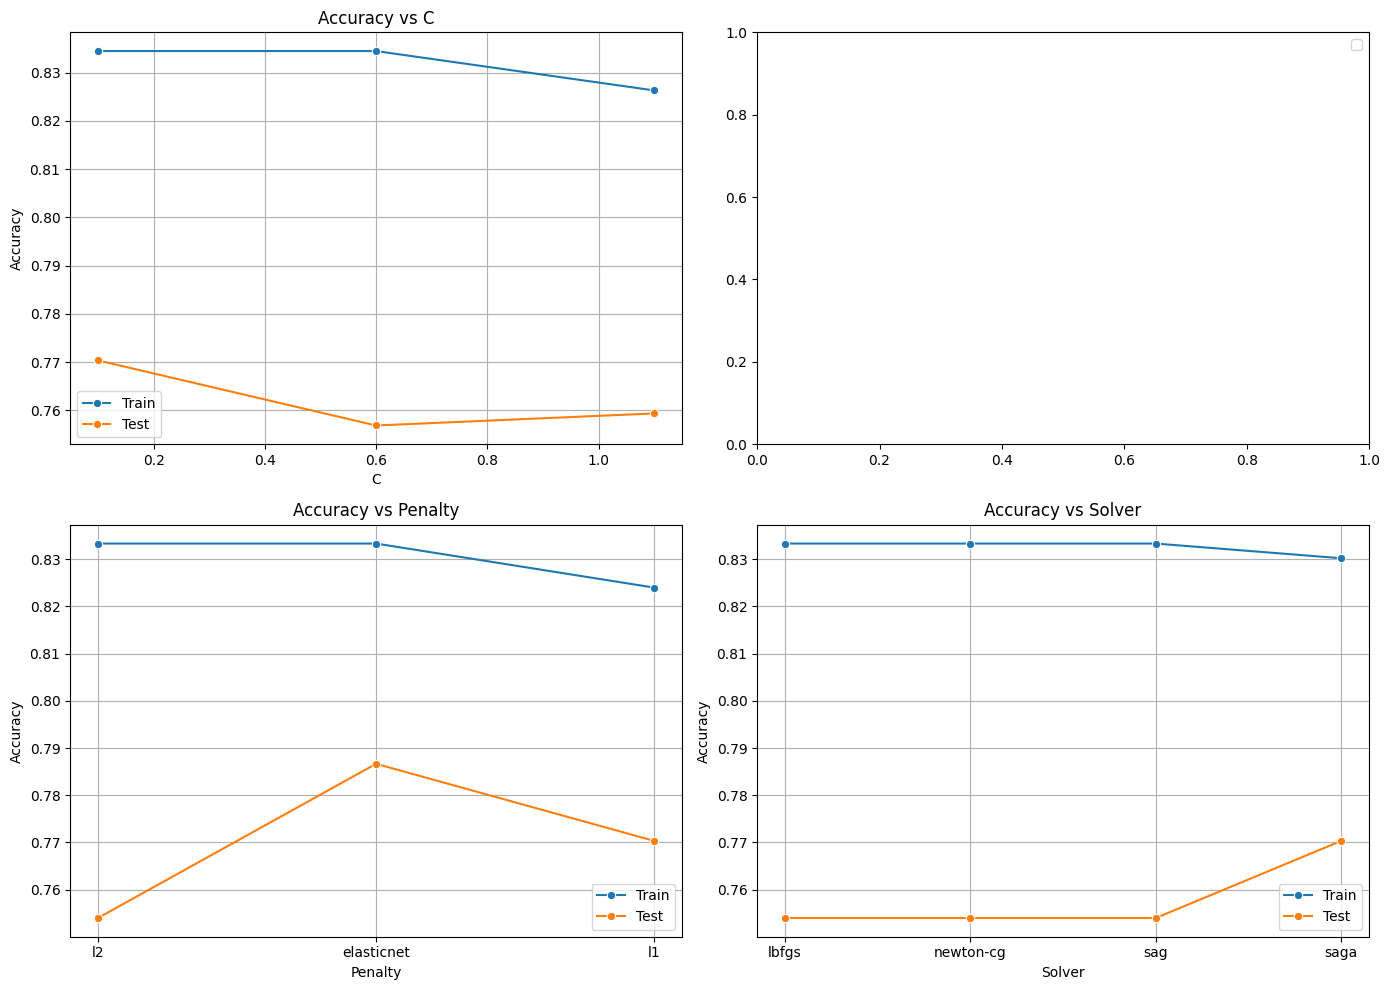

In [50]:
run_logistic_regression()
graph_logistic_regression()

In [51]:
def train_svc(X_train, y_train, kernel, C, degree, probability, gamma):
    model = svm.SVC(kernel=kernel, C=C, degree=degree, probability=probability, gamma=gamma)
    model.fit(X_train, y_train)
    return model

In [52]:
def run_svc():
    X, y, feature_names = read_data()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    degree=3;probability=True
    kernel= 'rbf'
    file= open('./training_results/svc.csv', mode='w', newline='', encoding='utf-8')
    header= 'C,gamma,probablity,f1_train,accuracy_train,f1_test,accuracy_test'
    file.write(header)
    for C in range(2,10,2):
        C=C/10
        for gamma in ['auto', 'scale']:
            model= train_svc(X_train, y_train, kernel, C, degree, probability, gamma)
            model_name= f'svc_{kernel}__{C}_{gamma}'
            if probability:
                model_name+='_with_probablity'
            y_pred = model.predict(X_test)
            pred= model.predict(X_train)
            f1_train = round(f1_score(y_train, pred, average='macro'),3)
            accuracy_train= round(accuracy_score(y_train, pred),3)
            f1_test = round(f1_score(y_test, y_pred, average='macro'),3)
            accuracy_test= round(accuracy_score(y_test, y_pred),3)
            cm = confusion_matrix(y_test, y_pred)
            save_cm('svc',model_name, cm)
            file.write('\n')
            data=[C,gamma,probability,accuracy_train,f1_train,accuracy_test,f1_test]
            line = ','.join(map(str, data))
            file.write(line)
            explain_model_using_shap(X_train,X_test, model,'svc', model_name, feature_names)
            explain_model_using_lime(X_train,X_test, model,'svc', model_name, feature_names)
                

In [53]:
def graph_svc():
    df = pd.read_csv('./training_results/svc.csv')
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    axs = axs.flatten()
    sns.lineplot(data=df, x='C', y='accuracy_train', ax=axs[0], marker='o', label='Train', errorbar=None)
    sns.lineplot(data=df, x='C', y='accuracy_test', ax=axs[0], marker='o', label='Test', errorbar=None)
    axs[0].set_title('Accuracy vs C')
    axs[0].set_xlabel('C')
    axs[0].set_ylabel('Accuracy')
    axs[0].grid(True)
    axs[0].legend()
    sns.lineplot(data=df, x='gamma', y='accuracy_train', ax=axs[2], marker='o', label='Train', errorbar=None)
    sns.lineplot(data=df, x='gamma', y='accuracy_test', ax=axs[2], marker='o', label='Test', errorbar=None)
    axs[2].set_title('Accuracy vs gamma')
    axs[2].set_xlabel('gamma')
    axs[2].set_ylabel('Accuracy')
    axs[2].grid(True)
    axs[2].legend()    
    axs[3].axis('off')
    plt.tight_layout()
    plt.show()


Using 142 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Outliers from age feature removed
Outliers from creatinine_phosphokinase feature removed
Outliers from ejection_fraction feature removed
Outliers from platelets feature removed
Outliers from serum_creatinine feature removed
Outliers from time feature removed


100%|██████████| 61/61 [01:03<00:00,  1.04s/it]
/Users/surafel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
Using 142 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


(1, 12)


100%|██████████| 61/61 [01:03<00:00,  1.04s/it]
/Users/surafel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
Using 142 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


...

100%|██████████| 61/61 [01:04<00:00,  1.06s/it]
/Users/surafel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
Using 142 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


(1, 12)


100%|██████████| 61/61 [01:03<00:00,  1.04s/it]


(1, 12)


/Users/surafel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


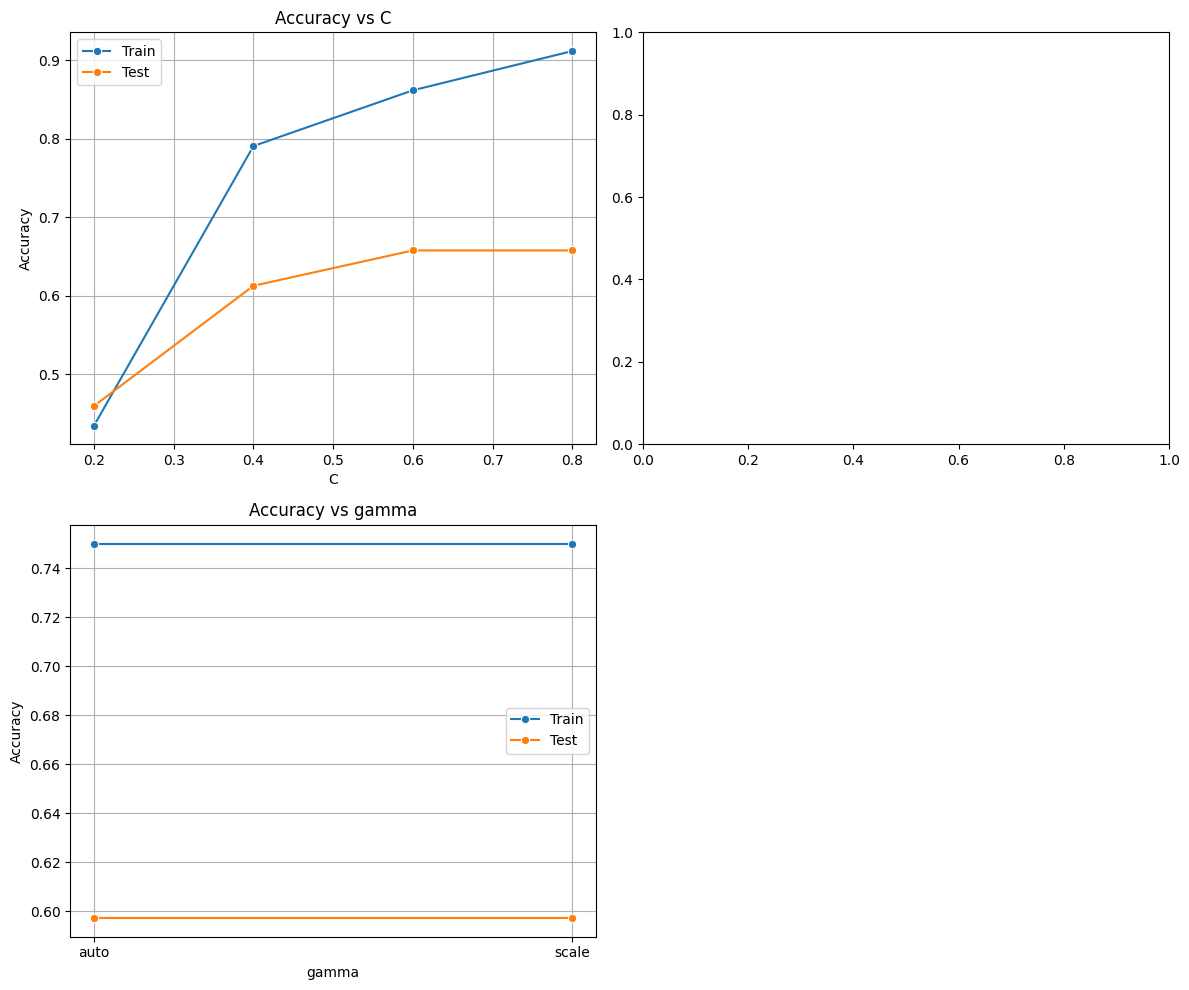

In [54]:
run_svc()
graph_svc()

In [55]:
def train_KNN(X_train, y_train, neighbours):
    model = KNeighborsClassifier(n_neighbors=neighbours)
    model.fit(X_train, y_train)
    return model

In [56]:
def run_knn():
    X, y, feature_names = read_data()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    model_name= f'knn'
    model= train_KNN(X_train, y_train, 2)
    y_pred = model.predict(X_test)
    pred= model.predict(X_train)
    f1_train = round(f1_score(y_train, pred, average='macro'),3)
    accuracy_train= round(accuracy_score(y_train, pred),3)
    f1_test = round(f1_score(y_test, y_pred, average='macro'),3)
    accuracy_test= round(accuracy_score(y_test, y_pred),3)
    print(
        f"KNN Training Results:\n"
        f"  Accuracy: {accuracy_train:.3f}\n"
        f"  F1 Score: {f1_train:.3f}\n"
        f"Test Results:\n"
        f"  Accuracy: {accuracy_test:.3f}\n"
        f"  F1 Score: {f1_test:.3f}"
    )
    cm = confusion_matrix(y_test, y_pred)
    save_cm('knn',model_name, cm)
    explain_model_using_shap(X_train,X_test, model,'knn', model_name, feature_names)
    explain_model_using_lime(X_train,X_test, model,'knn', model_name, feature_names)
        

In [57]:
run_knn()

Using 142 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Outliers from age feature removed
Outliers from creatinine_phosphokinase feature removed
Outliers from ejection_fraction feature removed
Outliers from platelets feature removed
Outliers from serum_creatinine feature removed
Outliers from time feature removed
KNN Training Results:
  Accuracy: 0.817
  F1 Score: 0.725
Test Results:
  Accuracy: 0.852
  F1 Score: 0.658


100%|██████████| 61/61 [03:58<00:00,  3.92s/it]


(1, 12)


/Users/surafel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
